In [23]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from src.Propeller import Propeller
from src.JobParameters import AerodynamicParameters, AcousticParameters

with open("../10x7E.pkl", "rb") as f:
    blade_dict = pickle.load(f)

In [24]:
aerodynamic_params = AerodynamicParameters(
    prop_radius=blade_dict['tip_radius'],
    hub_radius=blade_dict['hub_radius'],
    n_blades=blade_dict['n_blades'],
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
)

acoustic_params = AcousticParameters(
    aero_params=aerodynamic_params,
    p_ref=2e-5, revolutions=100, num_obs_times_per_rev=1000
)

In [25]:
v_inf = 0*np.ones(len(blade_dict['r']))

In [26]:
propeller = Propeller(
    propeller_geometry=blade_dict,
    aero_params=aerodynamic_params,
    acoustic_params=acoustic_params
)

propeller.run_bemt(v_inf=v_inf)

In [27]:
Ts,Qs, _, _ = propeller.compute_total_forces()

history_dTs, history_dQs = propeller.solution_data['dT'].values, propeller.solution_data['dQ'].values

In [28]:
vi_static = -v_inf[0]/2 + np.sqrt((v_inf[0]/2)**2 + (Ts/(2*aerodynamic_params.rho*np.pi*aerodynamic_params.prop_radius**2)))

BEMT Results: Thrust=8.2330 N, Torque=0.1373 N·m, Ct=0.118630, Cp=0.048952


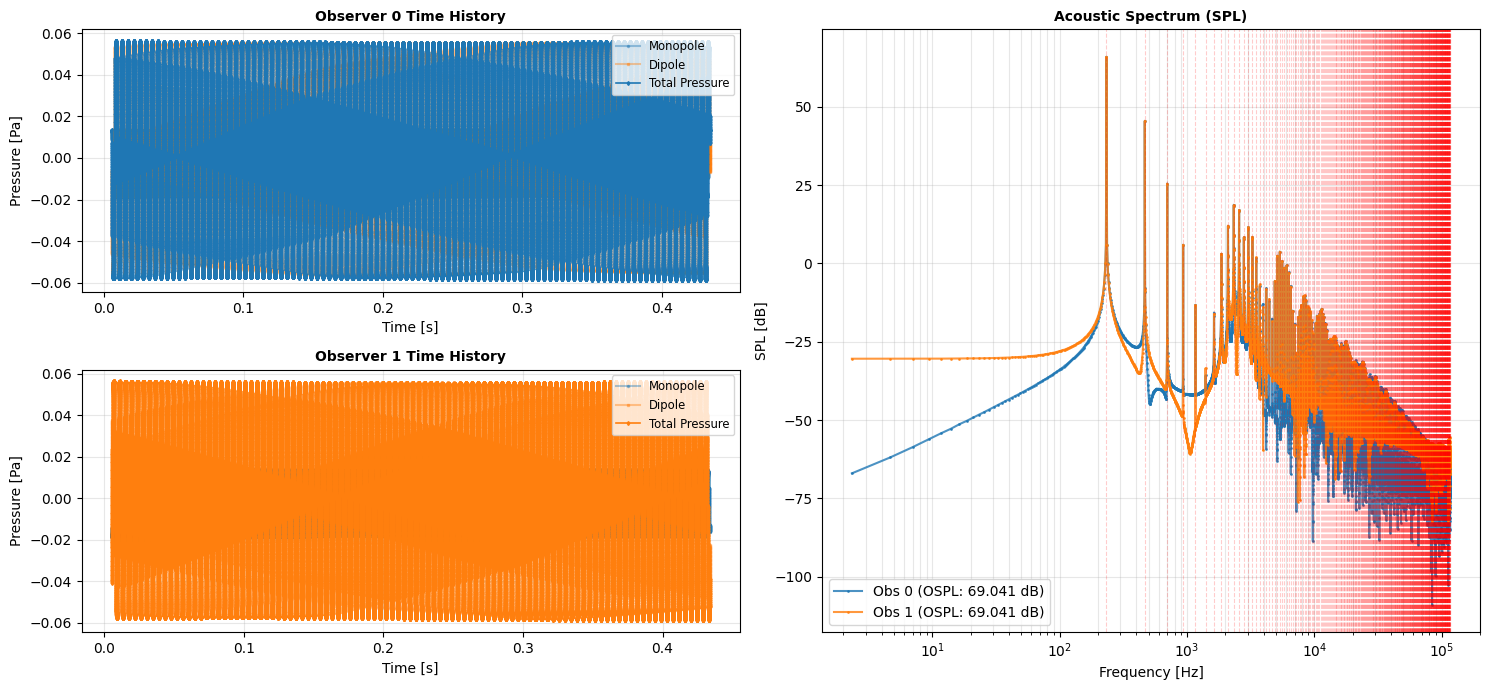

In [29]:
import matplotlib.gridspec as gridspec

r_observer = np.array([[0, 1.8, 0],
                        [0, 0, 1.8]])

# propeller.run_compact_f1a(observer_positions=r_observer)
propeller.run_compact_f1a(observer_positions=r_observer)

# Performance output
thrust, torque, ct, cp = propeller.compute_total_forces()
print(f"BEMT Results: Thrust={thrust:.4f} N, Torque={torque:.4f} N·m, Ct={ct:.6f}, Cp={cp:.6f}")

n_obs = r_observer.shape[0]
fig = plt.figure(figsize=(15, 3.5 * n_obs)) 
gs = gridspec.GridSpec(n_obs, 2, figure=fig)

fontsize = 10
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
blade_passing_freq = 1 / acoustic_params.blade_passing_period

ax_spl = fig.add_subplot(gs[:, 1])

for idx in range(n_obs):
    ax_time = fig.add_subplot(gs[idx, 0])
    color = colors[idx % len(colors)]
    
    ax_time.plot(propeller.t[:, idx], propeller.p_m[:, idx], 
                label='Monopole', linestyle='-', marker='o', markersize=1.5, alpha=0.4)
    ax_time.plot(propeller.t[:, idx], propeller.p_d[:, idx], 
                label='Dipole', linestyle='-', marker='s', markersize=1.5, alpha=0.4)
    ax_time.plot(propeller.t[:, idx], propeller.p_tot[:, idx], 
                color=color, linestyle='-', marker='d', markersize=2, 
                linewidth=1.2, label='Total Pressure')
    
    ax_time.set_title(f'Observer {idx} Time History', fontsize=fontsize, fontweight='bold')
    ax_time.set_xlabel('Time [s]', fontsize=fontsize)
    ax_time.set_ylabel('Pressure [Pa]', fontsize=fontsize)
    ax_time.grid(True, alpha=0.3)
    ax_time.legend(loc='upper right', fontsize='small')

    label_text = f'Obs {idx} (OSPL: {propeller.ospl[idx]:.3f} dB)'
    
    ax_spl.semilogx(propeller.freq[1:, idx], propeller.spl[1:, idx], 
                    color=color, linestyle='-', marker='.', markersize=2, 
                    label=label_text, alpha=0.8)

ax_spl.set_title('Acoustic Spectrum (SPL)', fontsize=fontsize, fontweight='bold')
ax_spl.set_xlabel('Frequency [Hz]', fontsize=fontsize)
ax_spl.set_ylabel('SPL [dB]', fontsize=fontsize)

max_f = np.max(propeller.freq)
harmonic_freqs = np.arange(blade_passing_freq, max_f, blade_passing_freq)
for bpf in harmonic_freqs:
    ax_spl.axvline(bpf, color='red', linestyle='--', linewidth=0.8, alpha=0.2)

ax_spl.grid(True, which='both', alpha=0.3)
ax_spl.legend(fontsize=fontsize, loc='lower left')
ax_spl.set_ylim()
plt.tight_layout()
plt.show()


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

def generate_3d_von_karman(Lx, Ly, Lz, nx, ny, nz, sigma, L_scale):
    # 1. Setup wavenumbers
    kx = 2 * np.pi * np.fft.fftfreq(nx, d=Lx/nx)
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=Ly/ny)
    kz = 2 * np.pi * np.fft.fftfreq(nz, d=Lz/nz)
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    K = np.sqrt(KX**2 + KY**2 + KZ**2)
    
    # 2. Von Karman Energy Spectrum E(k)
    with np.errstate(divide='ignore', invalid='ignore'):
        # Standard isotropic formulation
        E_k = (1.4528 * sigma**2 * L_scale * (L_scale * K)**4) / (1 + (L_scale * K)**2)**(17/6)
        psd = E_k / (4 * np.pi * K**2)
    psd[0, 0, 0] = 0
    
    # 3. Generate the 3D box via IFFT
    white_noise = np.random.normal(size=(nx, ny, nz)) + 1j * np.random.normal(size=(nx, ny, nz))
    box = np.fft.ifftn(np.sqrt(psd) * white_noise).real
    return (box - np.mean(box)) / np.std(box) * sigma

# Propeller Diameter is 0.25m
D = 0.25

# 1. Grid Dimensions (Tighten the box around the prop)
Ly, Lz = 0.4, 0.4     # 40cm x 40cm cross section
Lx = 5.0              # 5 meters of "wind" to fly through

# 2. Resolution (Aim for ~1cm resolution)
ny, nz = 64, 64       # Gives ~0.6cm resolution (0.4 / 64)
nx = 512              # Higher resolution in X for smooth derivatives (dL/dt)

sigma = 1           
# L_scale: Set to 1/2 of diameter to see spatial variation across blades
L_scale = 0.125       

u_box = generate_3d_von_karman(Lx, Ly, Lz, nx, ny, nz, sigma, L_scale)

nx, ny, nz = u_box.shape

from scipy.interpolate import RegularGridInterpolator

interp = RegularGridInterpolator(
    (np.linspace(0, Lx, nx), np.linspace(-Ly/2, Ly/2, ny), np.linspace(-Lz/2, Lz/2, nz)),
    u_box, bounds_error=False, fill_value=0
)

In [35]:
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

aero = propeller.aero_params
acoust = propeller.acoustic_params
df = propeller.solution_data

# Extract BEMT vectors
r = df['radius'].values
chord = df['chord'].values
twist = np.radians(df['twist'].values)
u_steady = df['u'].values
ap_steady = df['a_prime'].values

# --- 1. Setup Simulation ---
# Initialize position in the turbulence box
x_accum = 0.0 
v_inf_base = 0.0 # Your freestream velocity

# Storage for induction factors to compute adaptive V_scan
# We seed it with the steady state values from your 'df'
current_vi = u_steady

history_dT = np.zeros((len(propeller.acoustic_params.src_times), aero.n_blades, len(r)))
history_dQ = np.zeros((len(propeller.acoustic_params.src_times), aero.n_blades, len(r)))

# --- 2. The Unsteady Loop ---
for i, t in enumerate(propeller.acoustic_params.src_times):
    # Determine the adaptive advection speed
    # V_scan = V_inf + Average induced velocity across the disk
    v_avg_induced = np.average(current_vi)
    v_scan_current = v_inf_base + v_avg_induced
    
    # Increment x position based on the velocity of the current time step
    # x = integral of (V_inf + vi) dt
    x_accum += v_scan_current * propeller.acoustic_params.dt
    x_pos = x_accum % Lx  # Wrap around the box length
    
    for b in range(aero.n_blades):
        azimuth = propeller.aero_params.omega * t + (2 * np.pi * b / aero.n_blades)
        
        y_pts = r * np.cos(azimuth)
        z_pts = r * np.sin(azimuth)
        
        query_pts = np.vstack(([x_pos]*len(r), y_pts, z_pts)).T
        u_prime = interp(query_pts)
        
        # Run BEMT with the turbulent local v_inf
        propeller.run_bemt(v_inf = v_inf_base + u_prime)
        
        # Update our current_vi tracker for the next time step's advection
        # 'a' is the axial induction factor, vi = a * V_inf
        current_vi = propeller.solution_data['u'].values
        
        history_dT[i, b, :] = propeller.solution_data['dT'].values/aerodynamic_params.n_blades
        history_dQ[i, b, :] = propeller.solution_data['dQ'].values/aerodynamic_params.n_blades

    # Compute forces for the whole disk at this timestamp
    T, Q, _, _ = propeller.compute_total_forces()
    print(f"Step {i+1}/{len(propeller.acoustic_params.src_times)} | V_scan: {v_scan_current:.3f} m/s | Total T: {T:.4f} N")

Step 1/2000 | V_scan: 7.712 m/s | Total T: 8.2402 N
Step 2/2000 | V_scan: 8.037 m/s | Total T: 8.1559 N
Step 3/2000 | V_scan: 8.500 m/s | Total T: 8.1236 N
Step 4/2000 | V_scan: 8.360 m/s | Total T: 8.1167 N
Step 5/2000 | V_scan: 8.214 m/s | Total T: 8.0809 N
Step 6/2000 | V_scan: 7.903 m/s | Total T: 8.2001 N
Step 7/2000 | V_scan: 7.738 m/s | Total T: 8.2438 N
Step 8/2000 | V_scan: 7.995 m/s | Total T: 8.2406 N
Step 9/2000 | V_scan: 8.033 m/s | Total T: 8.2500 N
Step 10/2000 | V_scan: 8.109 m/s | Total T: 8.2293 N
Step 11/2000 | V_scan: 8.035 m/s | Total T: 8.3223 N
Step 12/2000 | V_scan: 7.862 m/s | Total T: 8.2333 N
Step 13/2000 | V_scan: 7.837 m/s | Total T: 8.2896 N
Step 14/2000 | V_scan: 7.622 m/s | Total T: 8.1870 N
Step 15/2000 | V_scan: 7.697 m/s | Total T: 8.2426 N
Step 16/2000 | V_scan: 7.686 m/s | Total T: 8.2073 N
Step 17/2000 | V_scan: 7.806 m/s | Total T: 8.2039 N
Step 18/2000 | V_scan: 7.852 m/s | Total T: 8.0930 N
Step 19/2000 | V_scan: 7.997 m/s | Total T: 8.0970 N
St

In [32]:
history_T = np.sum(history_dT, axis=(1,2))
history_Q = np.sum(history_dQ, axis=(1,2))

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Davide Pusino\AppData\Local\Temp\ipykernel_21572\1375162850.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Unsteady Propeller Thrust History\n(Turbulent Inflow $\sigma$={sigma} m/s)", fontsize=14)


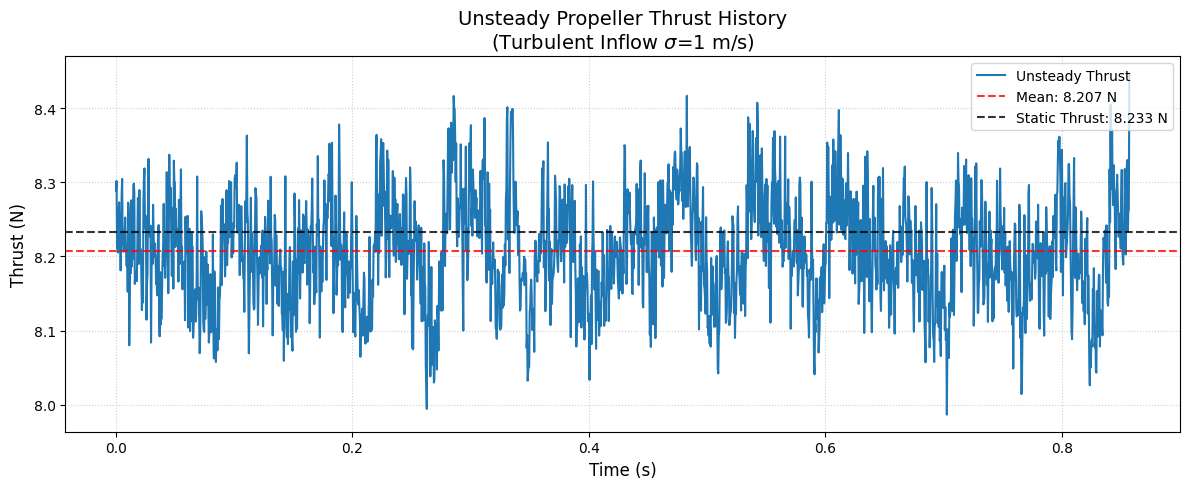

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5), dpi=100)
plt.plot(propeller.acoustic_params.src_times, history_T, label='Unsteady Thrust', color='#1f77b4', lw=1.5)
plt.axhline(y=np.mean(history_T), color='red', linestyle='--', alpha=0.8, label=f'Mean: {np.mean(history_T):.3f} N')
plt.axhline(y=Ts, color='k', linestyle='--', alpha=0.8, label=f'Static Thrust: {Ts:.3f} N')

plt.title(f"Unsteady Propeller Thrust History\n(Turbulent Inflow $\sigma$={sigma} m/s)", fontsize=14)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Thrust (N)", fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

BEMT Results: Thrust=8.5432 N, Torque=0.1439 N·m, Ct=0.123099, Cp=0.051294


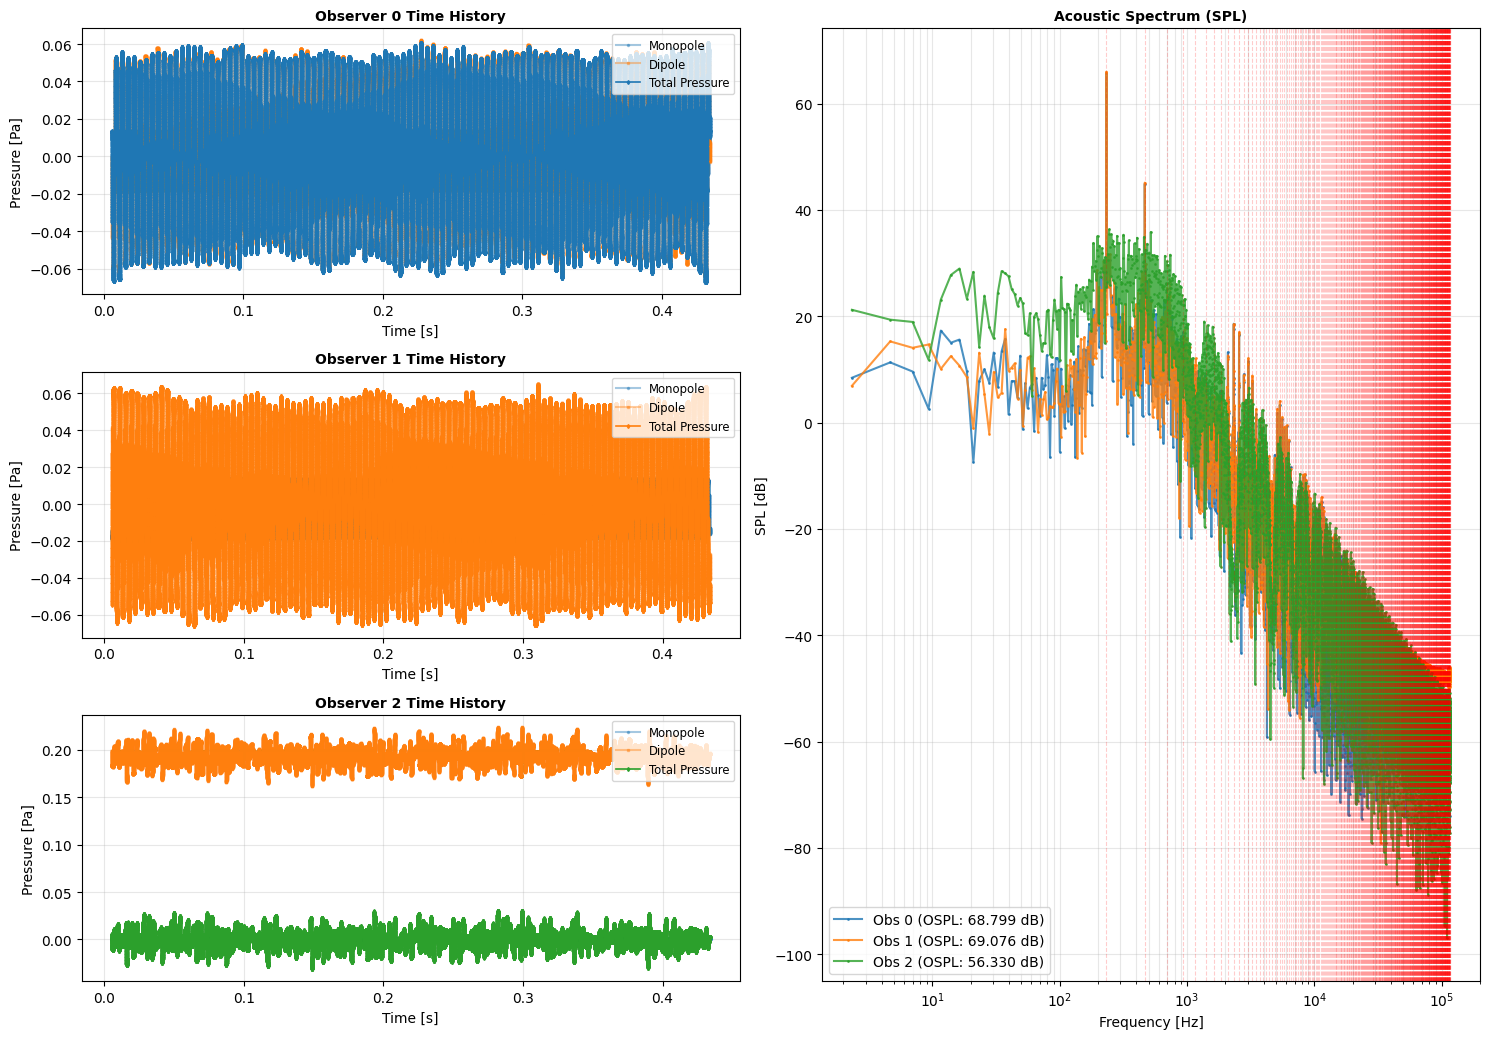

In [34]:
import matplotlib.gridspec as gridspec

r_observer = np.array([[0, 1.8, 0],
                        [0, 0, 1.8],
                        [1.8, 0, 0]])

propeller.run_compact_f1a(observer_positions=r_observer, local_dT=history_dT, local_dQ=history_dQ)

# Performance output
thrust, torque, ct, cp = propeller.compute_total_forces()
print(f"BEMT Results: Thrust={thrust:.4f} N, Torque={torque:.4f} N·m, Ct={ct:.6f}, Cp={cp:.6f}")

n_obs = r_observer.shape[0]
fig = plt.figure(figsize=(15, 3.5 * n_obs)) 
gs = gridspec.GridSpec(n_obs, 2, figure=fig)

fontsize = 10
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
blade_passing_freq = 1 / acoustic_params.blade_passing_period

ax_spl = fig.add_subplot(gs[:, 1])

for idx in range(n_obs):
    ax_time = fig.add_subplot(gs[idx, 0])
    color = colors[idx % len(colors)]
    
    ax_time.plot(propeller.t[:, idx], propeller.p_m[:, idx], 
                label='Monopole', linestyle='-', marker='o', markersize=1.5, alpha=0.4)
    ax_time.plot(propeller.t[:, idx], propeller.p_d[:, idx], 
                label='Dipole', linestyle='-', marker='s', markersize=1.5, alpha=0.4)
    ax_time.plot(propeller.t[:, idx], propeller.p_tot[:, idx], 
                color=color, linestyle='-', marker='d', markersize=2, 
                linewidth=1.2, label='Total Pressure')
    
    ax_time.set_title(f'Observer {idx} Time History', fontsize=fontsize, fontweight='bold')
    ax_time.set_xlabel('Time [s]', fontsize=fontsize)
    ax_time.set_ylabel('Pressure [Pa]', fontsize=fontsize)
    ax_time.grid(True, alpha=0.3)
    ax_time.legend(loc='upper right', fontsize='small')

    label_text = f'Obs {idx} (OSPL: {propeller.ospl[idx]:.3f} dB)'
    
    ax_spl.semilogx(propeller.freq[1:, idx], propeller.spl[1:, idx], 
                    color=color, linestyle='-', marker='.', markersize=2, 
                    label=label_text, alpha=0.8)

ax_spl.set_title('Acoustic Spectrum (SPL)', fontsize=fontsize, fontweight='bold')
ax_spl.set_xlabel('Frequency [Hz]', fontsize=fontsize)
ax_spl.set_ylabel('SPL [dB]', fontsize=fontsize)

max_f = np.max(propeller.freq)
harmonic_freqs = np.arange(blade_passing_freq, max_f, blade_passing_freq)
for bpf in harmonic_freqs:
    ax_spl.axvline(bpf, color='red', linestyle='--', linewidth=0.8, alpha=0.2)

ax_spl.grid(True, which='both', alpha=0.3)
ax_spl.legend(fontsize=fontsize, loc='lower left')
ax_spl.set_ylim()
plt.tight_layout()
plt.show()